# Passive Brachiation Report

This notebook is the report entry point. Each section calls the corresponding cached `run()` function and displays the generated figure. Set `FORCE = True` to recompute all sections.

In [2]:
from IPython.display import Image, display

FORCE = False
RESULTS_DIR = "results"

def show(result, name="main"):
    path = result.figure(name)
    print(path)
    display(Image(filename=str(path)))

## 1. Physical Model

Ordinary underactuated two-link brachiation model, including workspace motion, state portraits, and energy history for a representative passive rollout.

[part1_modeling] cache hit (c870a1f8ce67); reused 1 figure(s).
results\part1_modeling_c870a1f8ce67__main.png


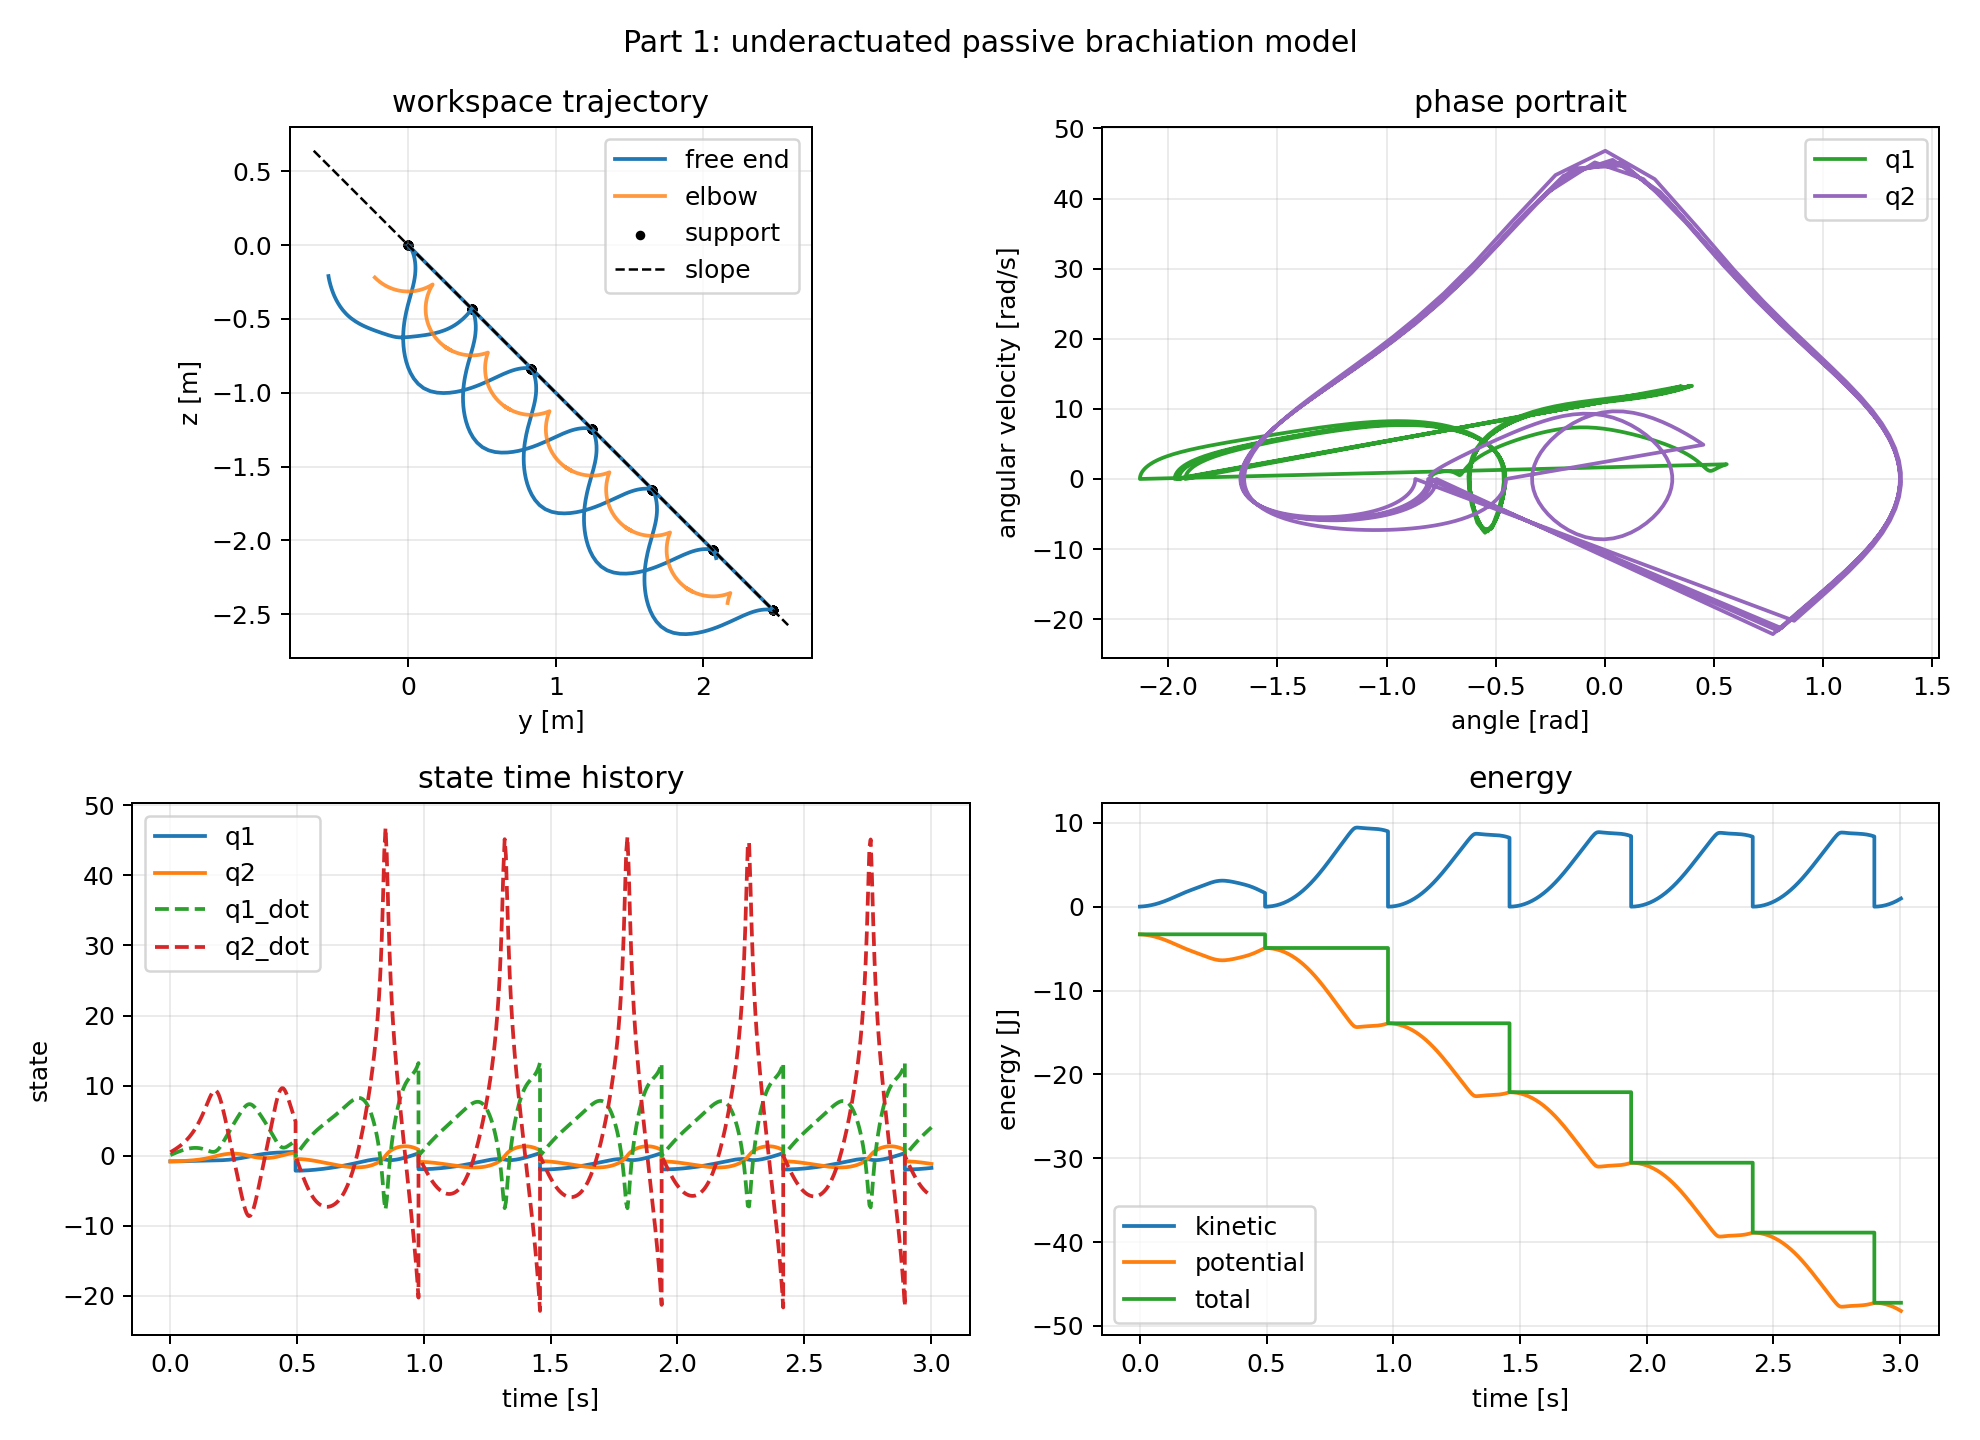

In [3]:
from run_part1_modeling import run as run_part1

part1 = run_part1(force=FORCE, results_dir=RESULTS_DIR)
show(part1)

## 2. Passive Steady Gait

For a fixed parameter set, find a passive fixed gait and visualize its repeated state trajectory and energy evolution.

[part2_steady_state] cache hit (f63b735f7e13); reused 1 figure(s).
results\part2_steady_state_f63b735f7e13__main.png


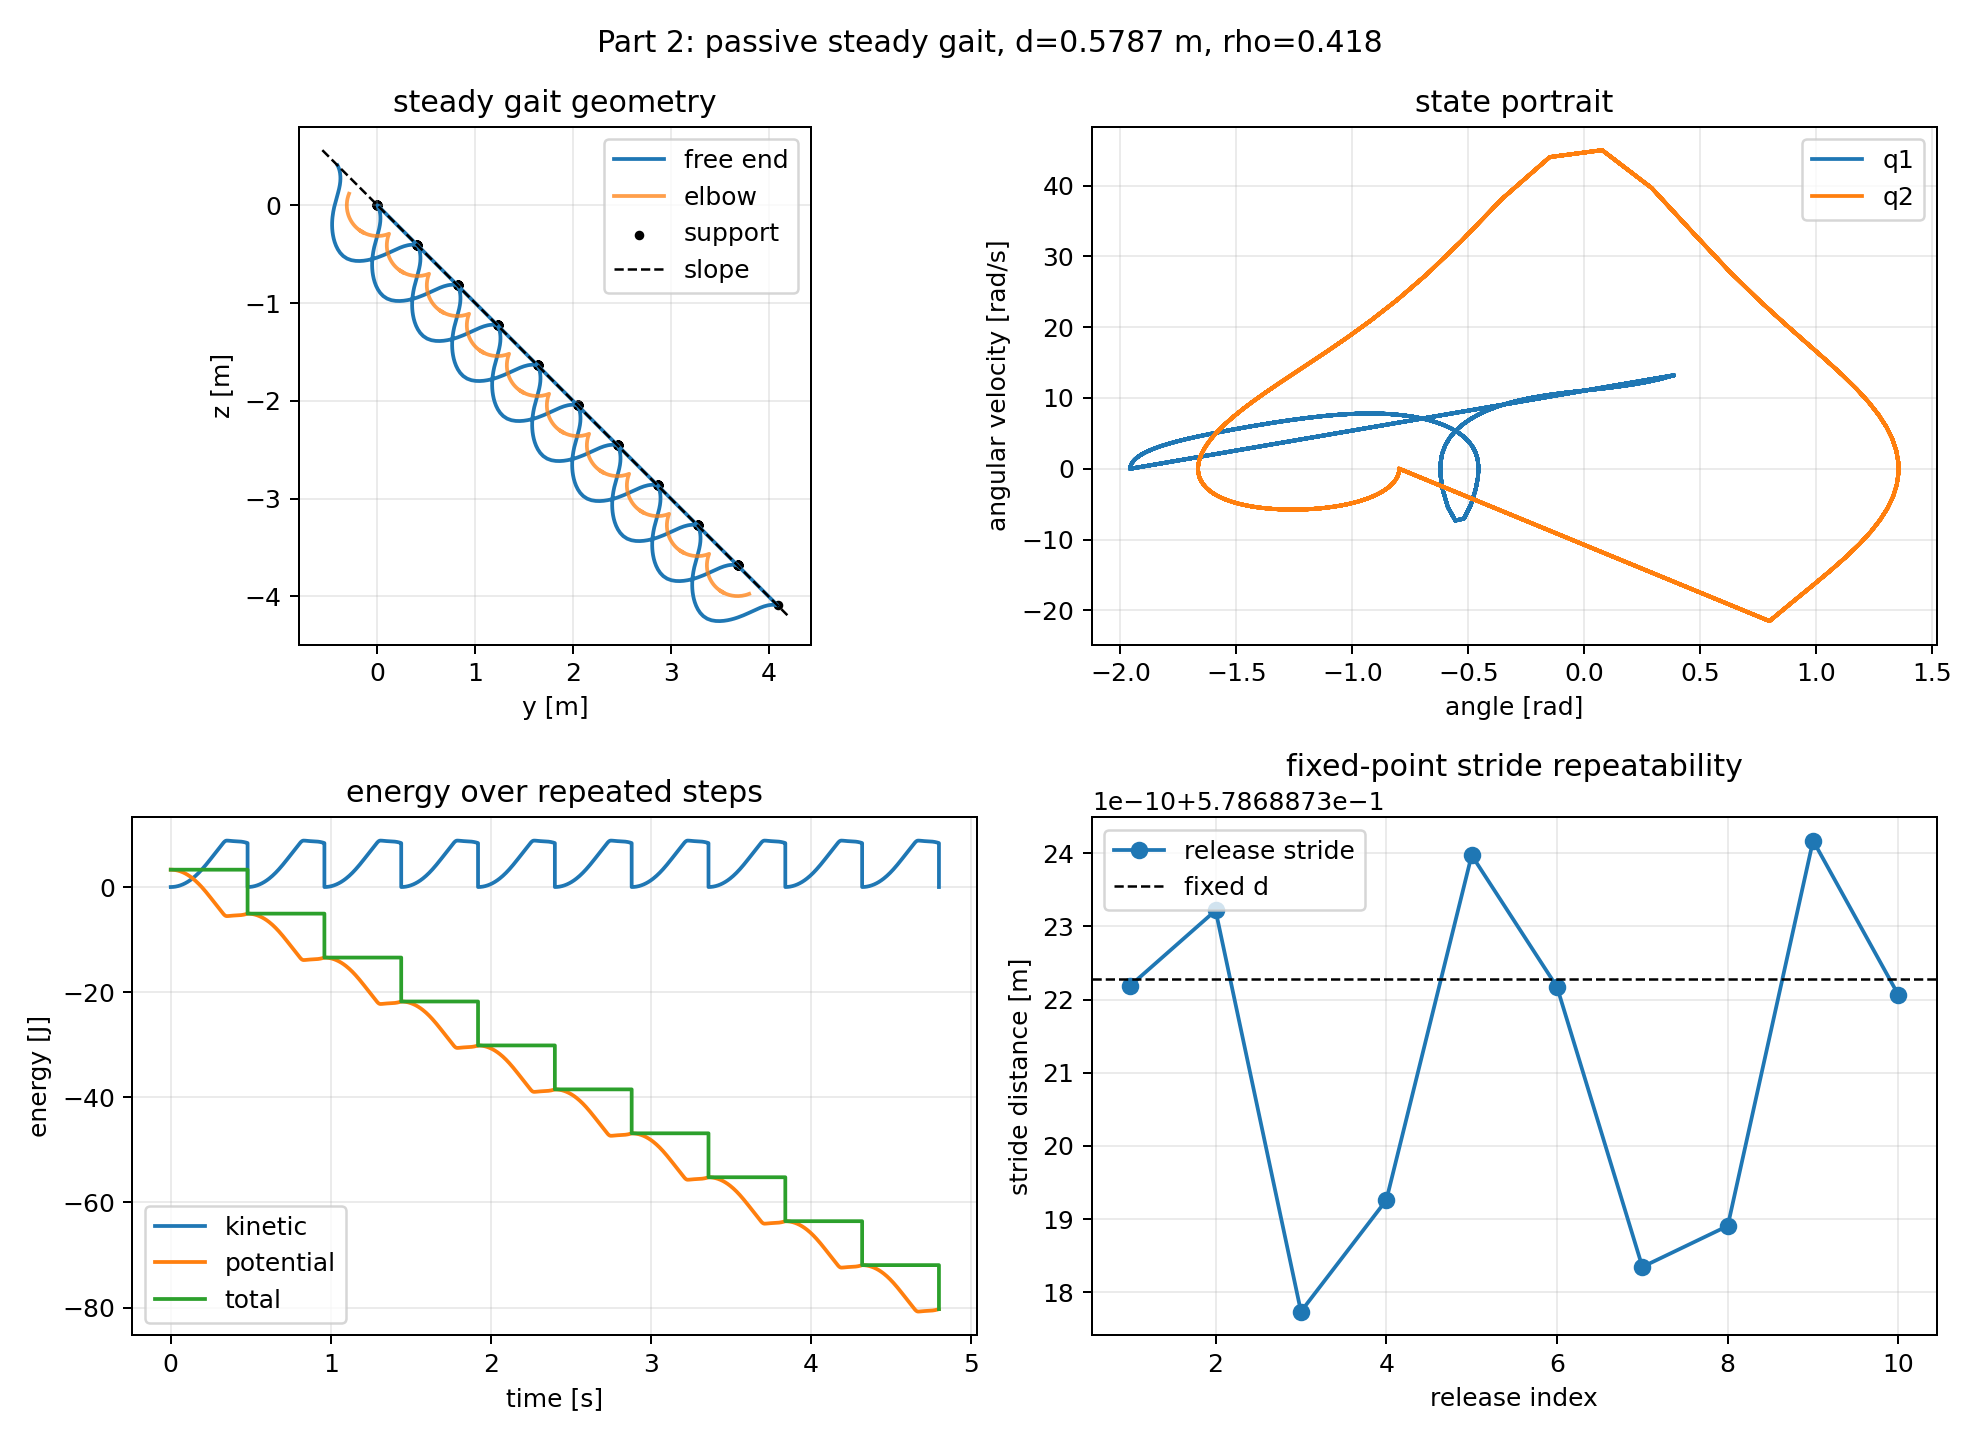

{'branch': 'negative',
 'd_fixed': 0.5786887322285337,
 'legal': True,
 'period': 1,
 'release_stride_mean': 0.5786887321203377,
 'spectral_radius': 0.4183269107671527,
 'stable': True,
 'validation_error': 3.296062311974879e-10}

In [4]:
from run_part2_steady_state import run as run_part2

part2 = run_part2(force=FORCE, results_dir=RESULTS_DIR)
show(part2)
part2.summary

## 3a. COM Sweep

Sweep symmetric COM offset and track how the passive fixed gait evolves.

[com_sweep] cache hit (e25fb62fb64a); reused 1 figure(s).
results\com_sweep_e25fb62fb64a__main.png


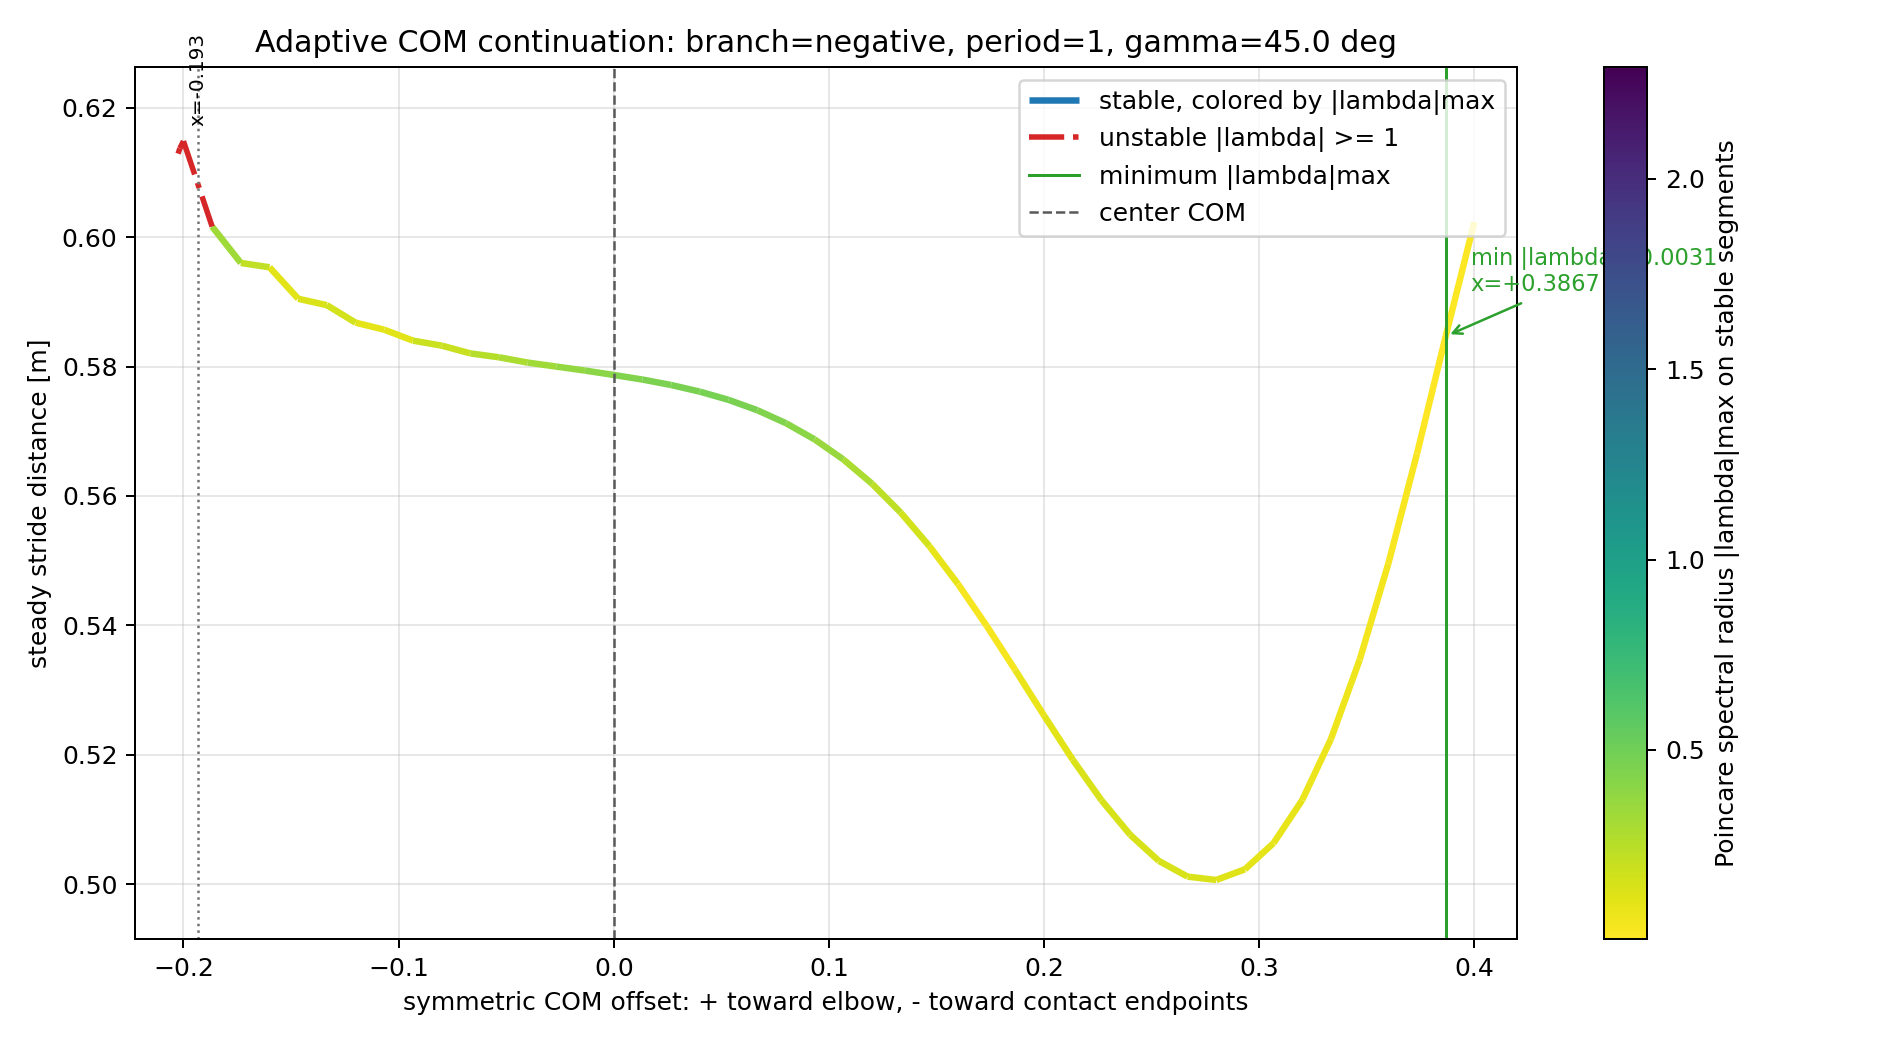

In [5]:
from run_com_sweep import run as run_com_sweep

part3a = run_com_sweep(force=FORCE, results_dir=RESULTS_DIR)
show(part3a)

## 3b. Lower-Limit Fold / Saddle-Node Search

Analyze the suspected lower-limit instability and its stable/unstable branch structure.

[com_special_point] cache hit (caafd073c91b); reused 2 figure(s).
results\com_special_point_caafd073c91b__fine_scan.png


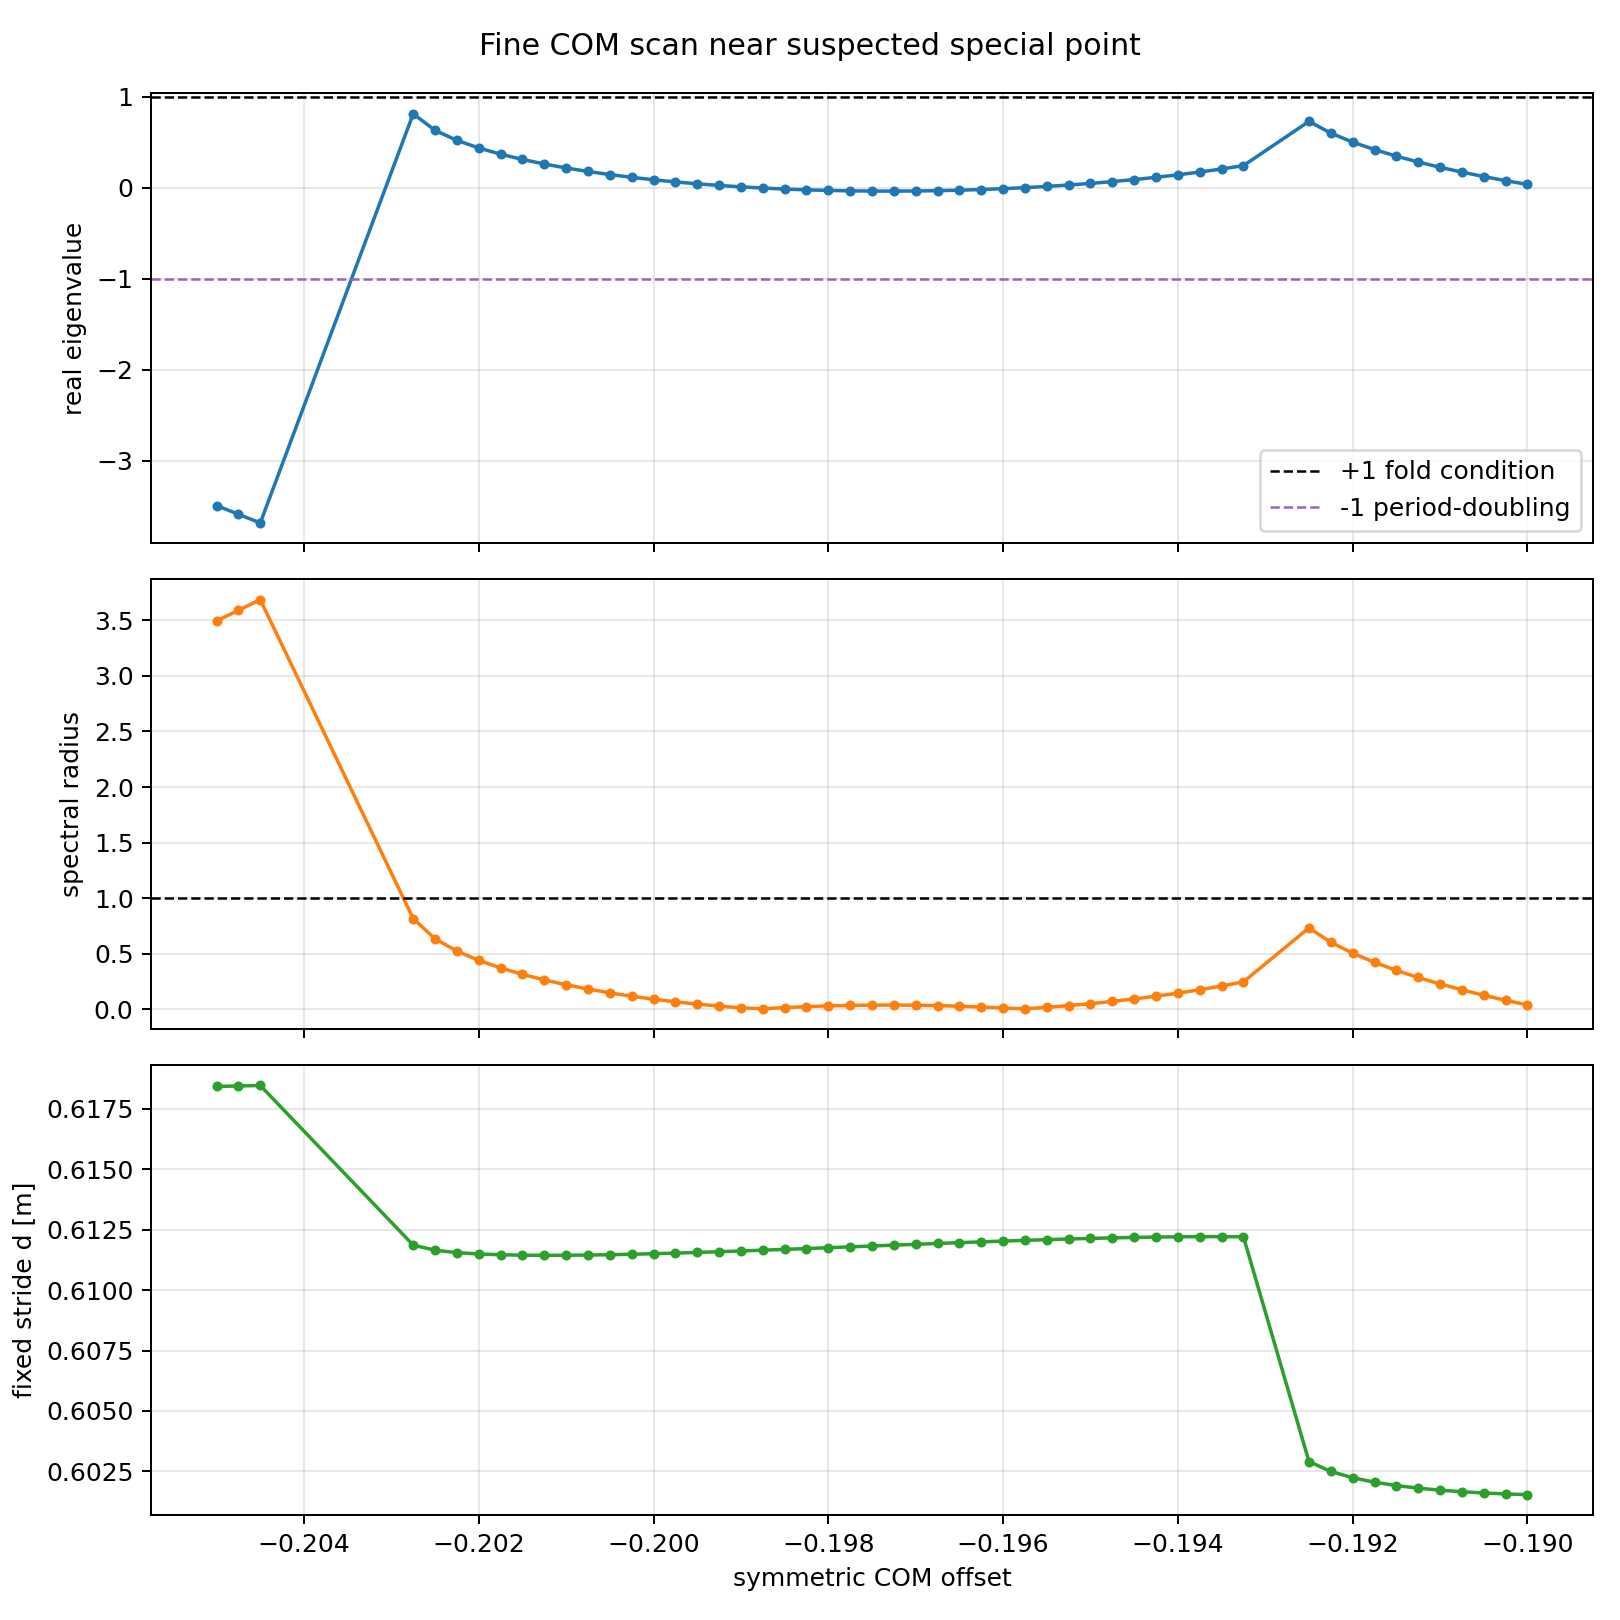

results\com_special_point_caafd073c91b__fold_arms.png


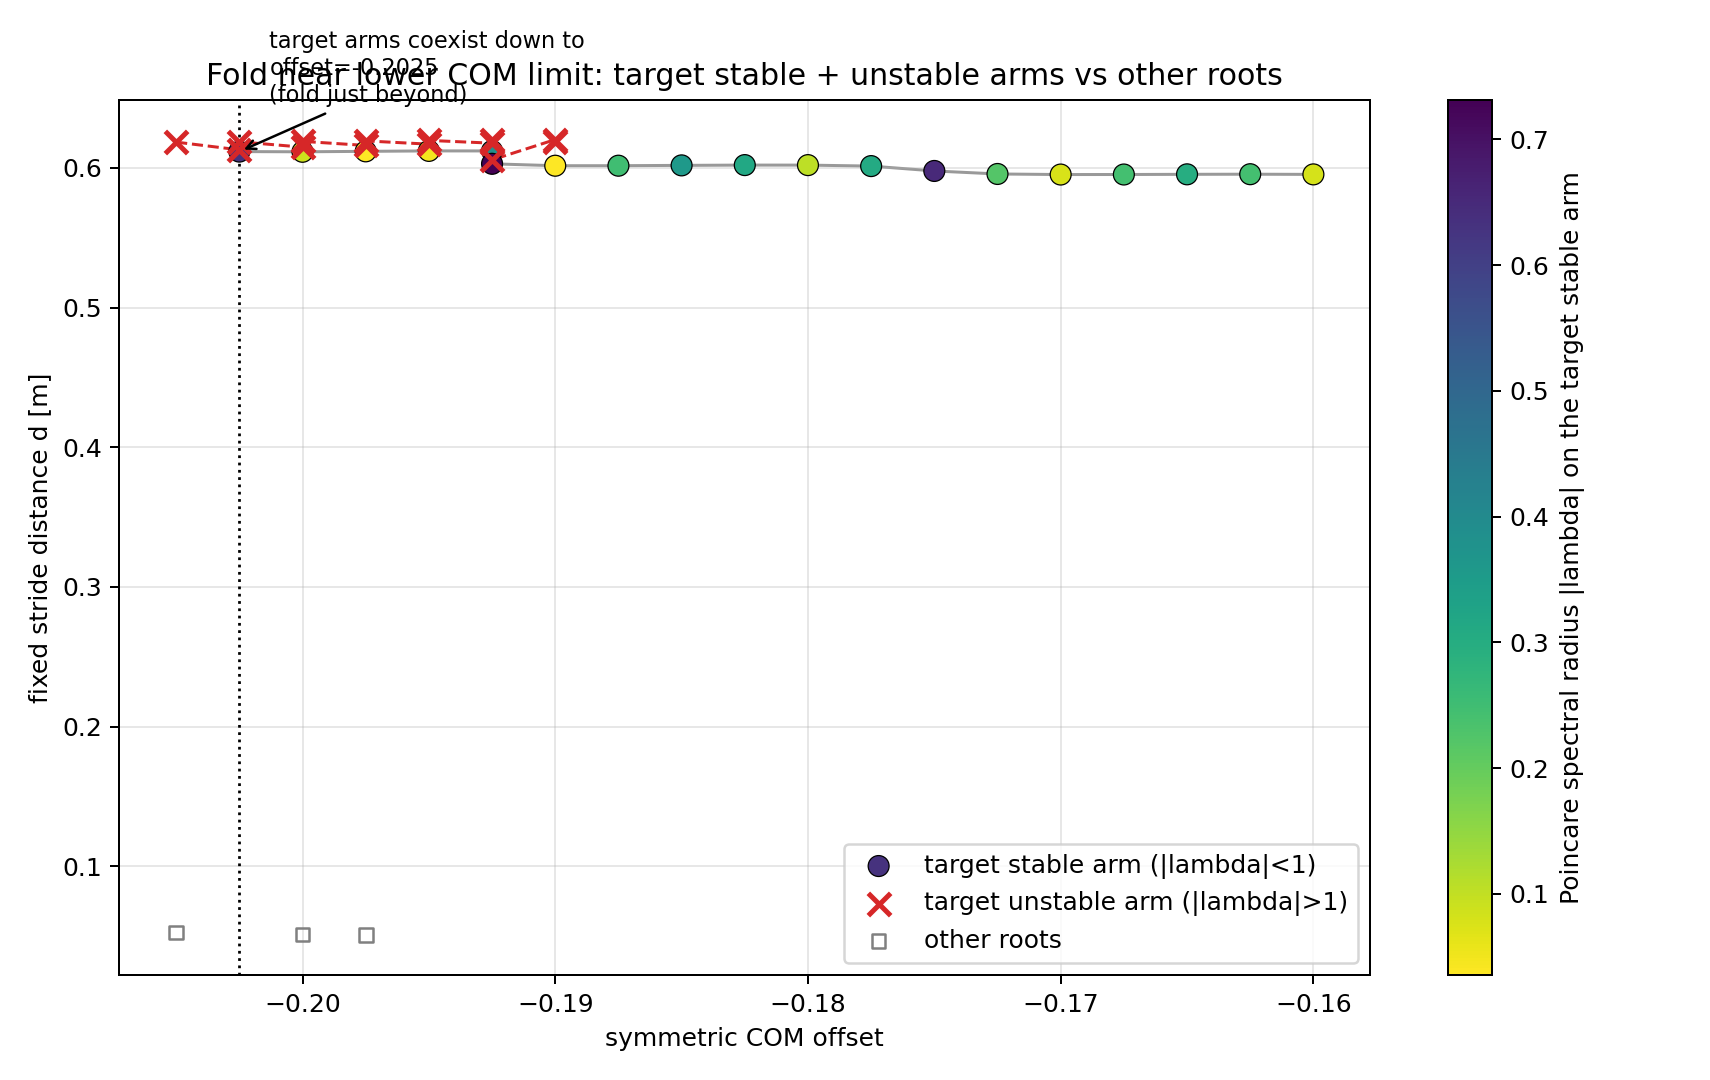

In [6]:
from run_com_special_point_analysis import run as run_special

part3b = run_special(force=FORCE, results_dir=RESULTS_DIR)
show(part3b, "fine_scan")
show(part3b, "fold_arms")

## 3c. Slope Sweep

Using the COM-selected operating point, vary slope angle and monitor stability/legal fixed-gait continuation.

[gamma_sweep] cache hit (a78193178db3); reused 1 figure(s).
results\gamma_sweep_a78193178db3__main.png


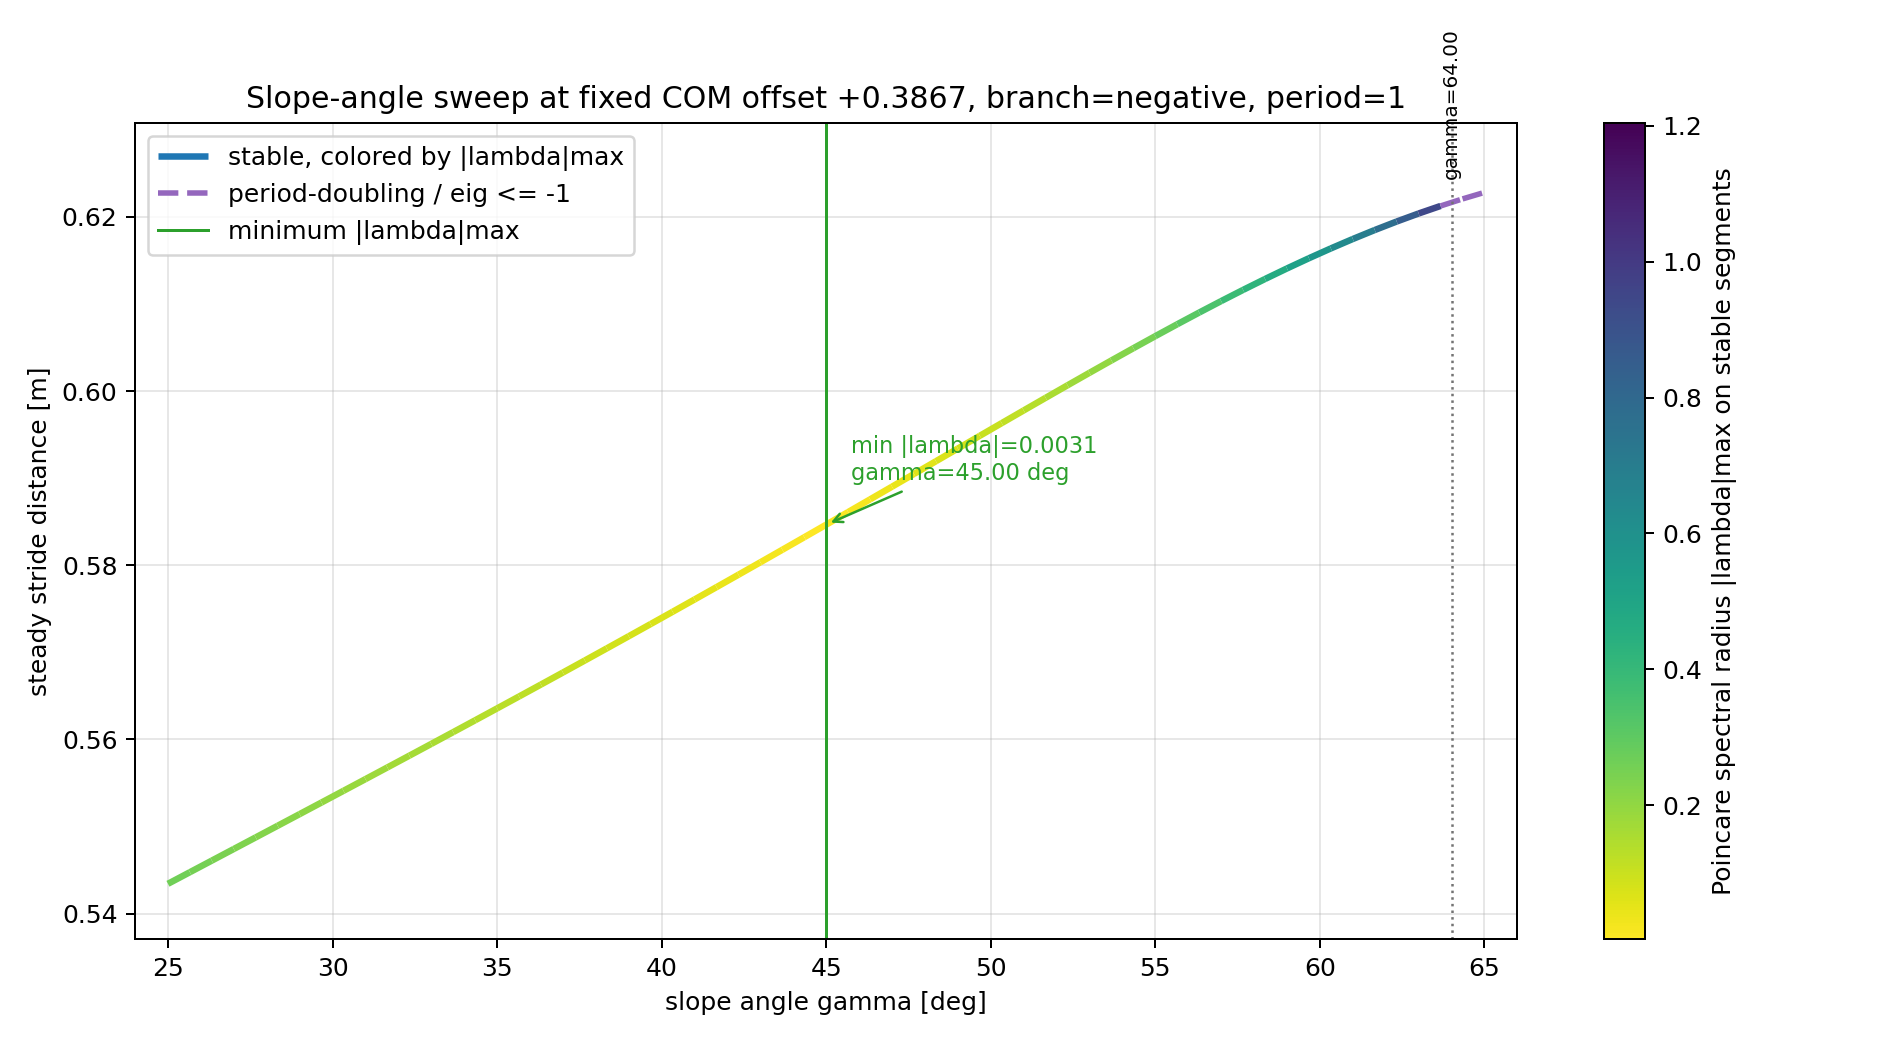

In [7]:
from run_gamma_sweep import run as run_gamma

part3c = run_gamma(force=FORCE, results_dir=RESULTS_DIR)
show(part3c)

## 4. One-Step Basin Probe

Plot `d_k -> d_{k+1}` error maps for automatically selected stable, near-critical, and unstable COM offsets.

[com_stride_map_family] cache hit (83eb2629728b); reused 1 figure(s).
results\com_stride_map_family_83eb2629728b__main.png


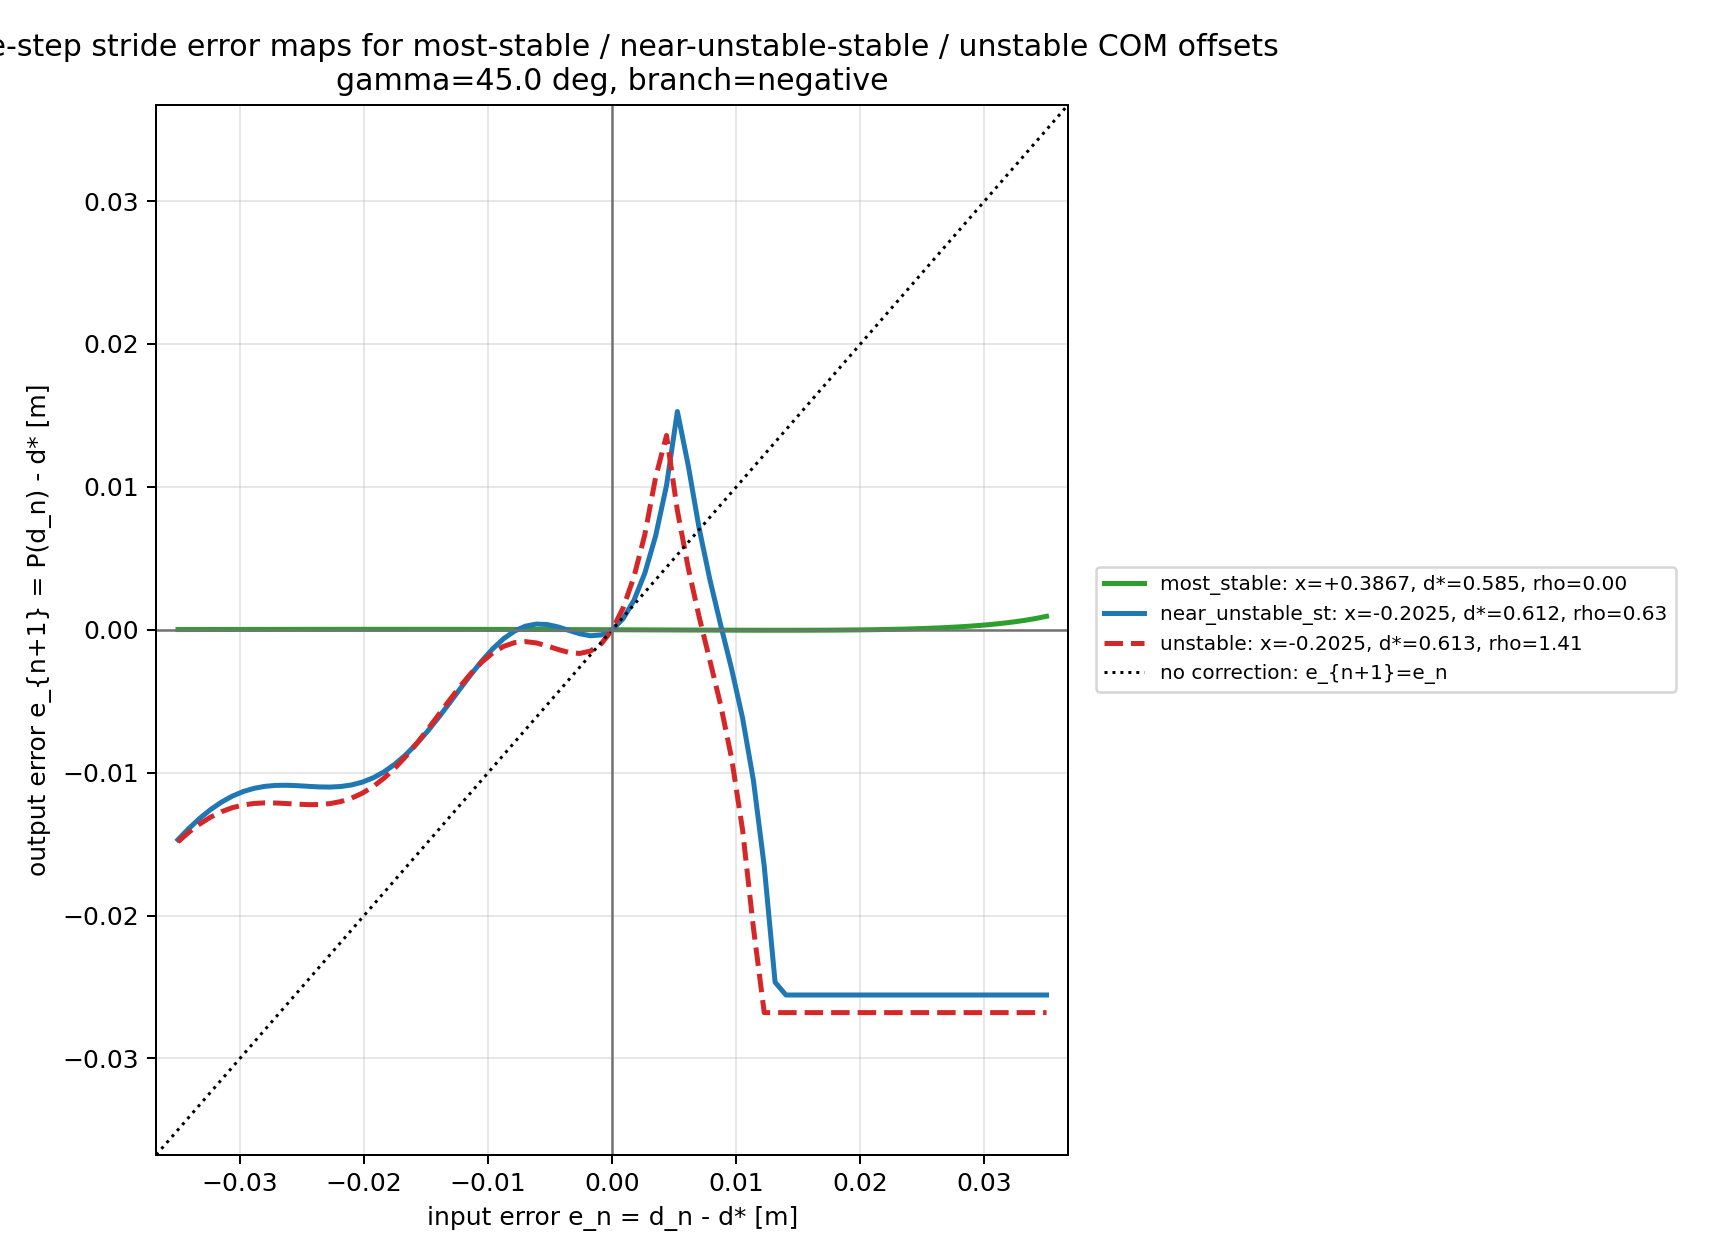

In [8]:
from run_com_stride_map_family import run as run_stride_family

part4 = run_stride_family(force=FORCE, results_dir=RESULTS_DIR)
show(part4)

## 5. Normal-Velocity Compensation

As the slope is lowered, inject endpoint normal velocity at release to preserve the same target stride.

[normal_velocity_gamma_continuation] cache hit (c5ac797ba48b); reused 1 figure(s).
results\normal_velocity_gamma_continuation_c5ac797ba48b__main.png


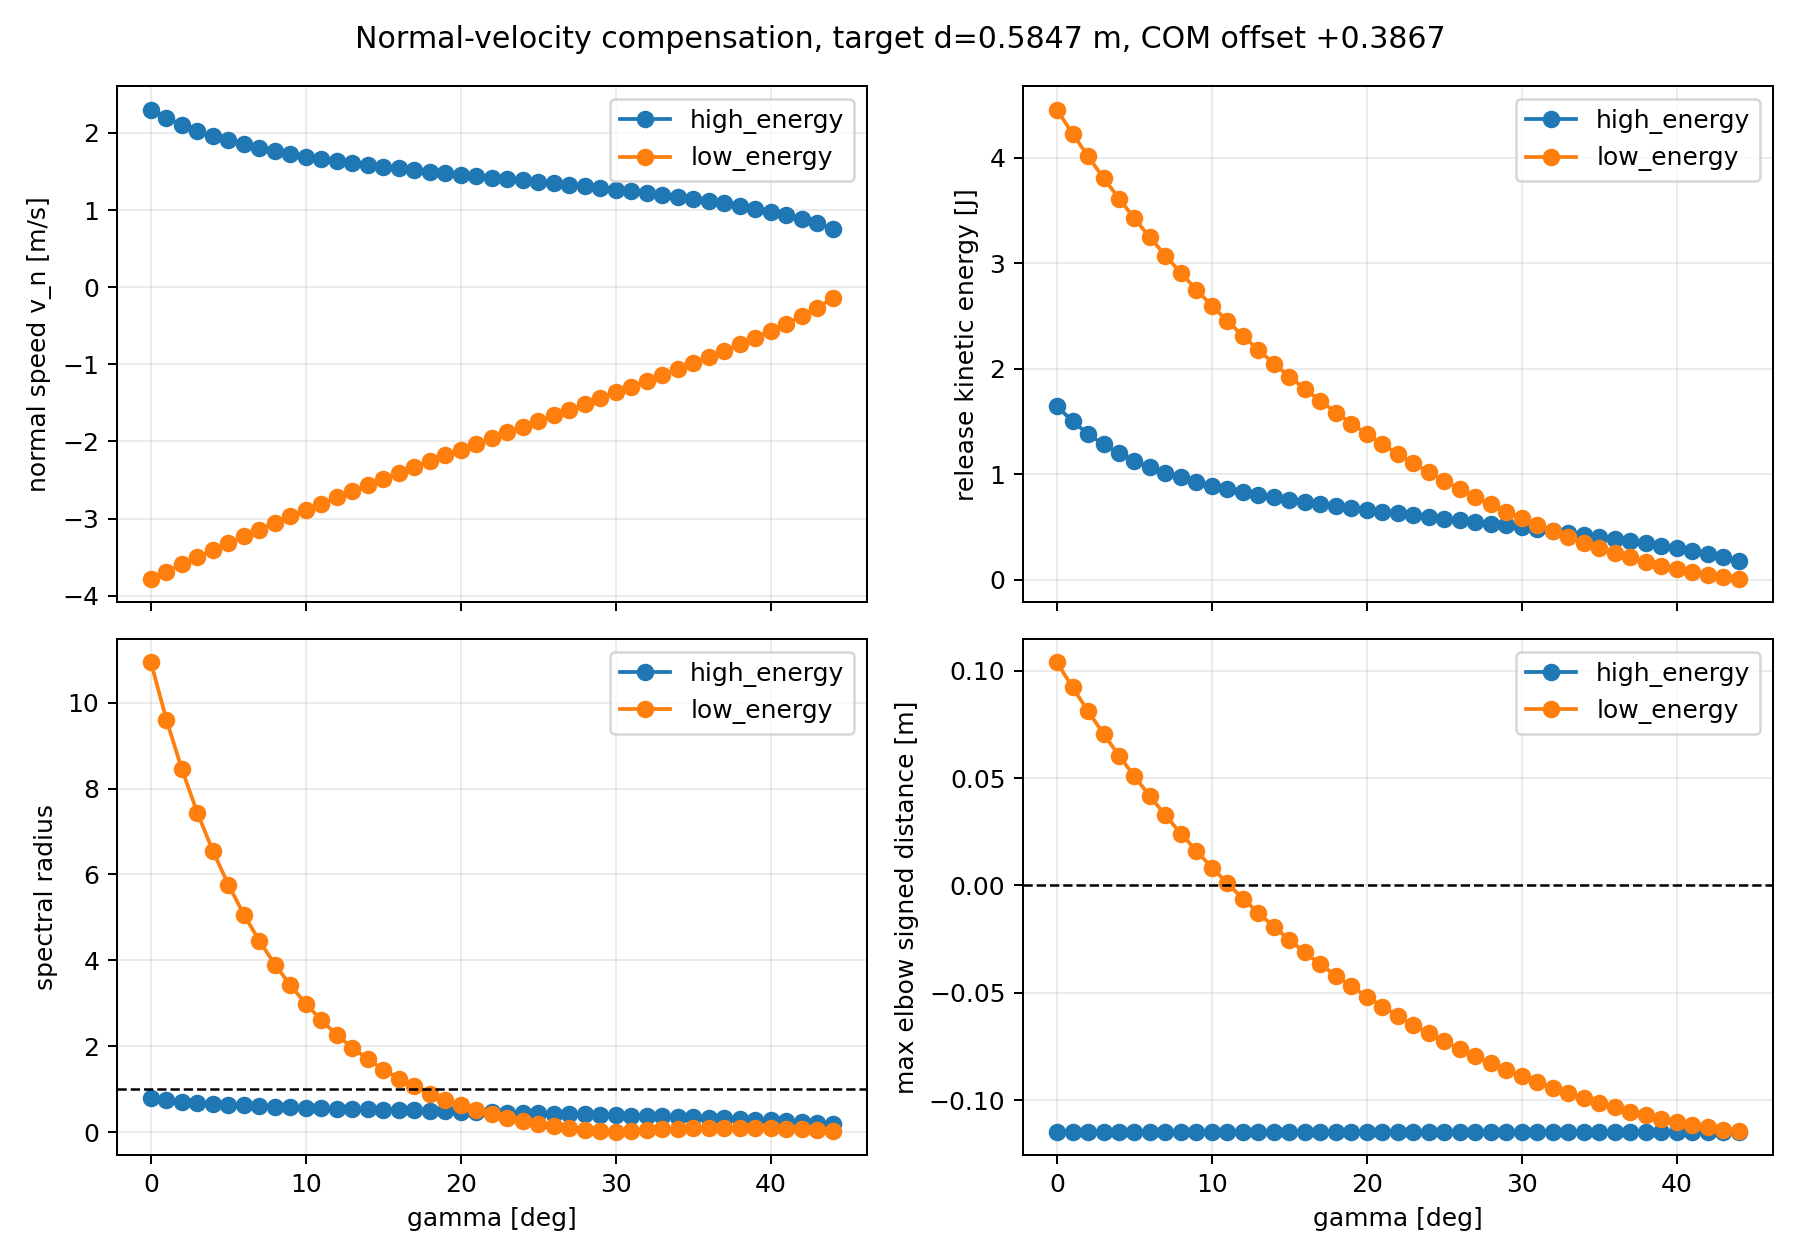

In [9]:
from run_normal_velocity_gamma_continuation import run as run_normal_velocity

part5 = run_normal_velocity(force=FORCE, results_dir=RESULTS_DIR)
show(part5)

## 6. Normal-Impulse Compensation

Replace the prescribed normal velocity with a physically motivated endpoint normal impulse.

[normal_impulse_gamma_continuation] cache hit (5922025c5471); reused 1 figure(s).
results\normal_impulse_gamma_continuation_5922025c5471__main.png


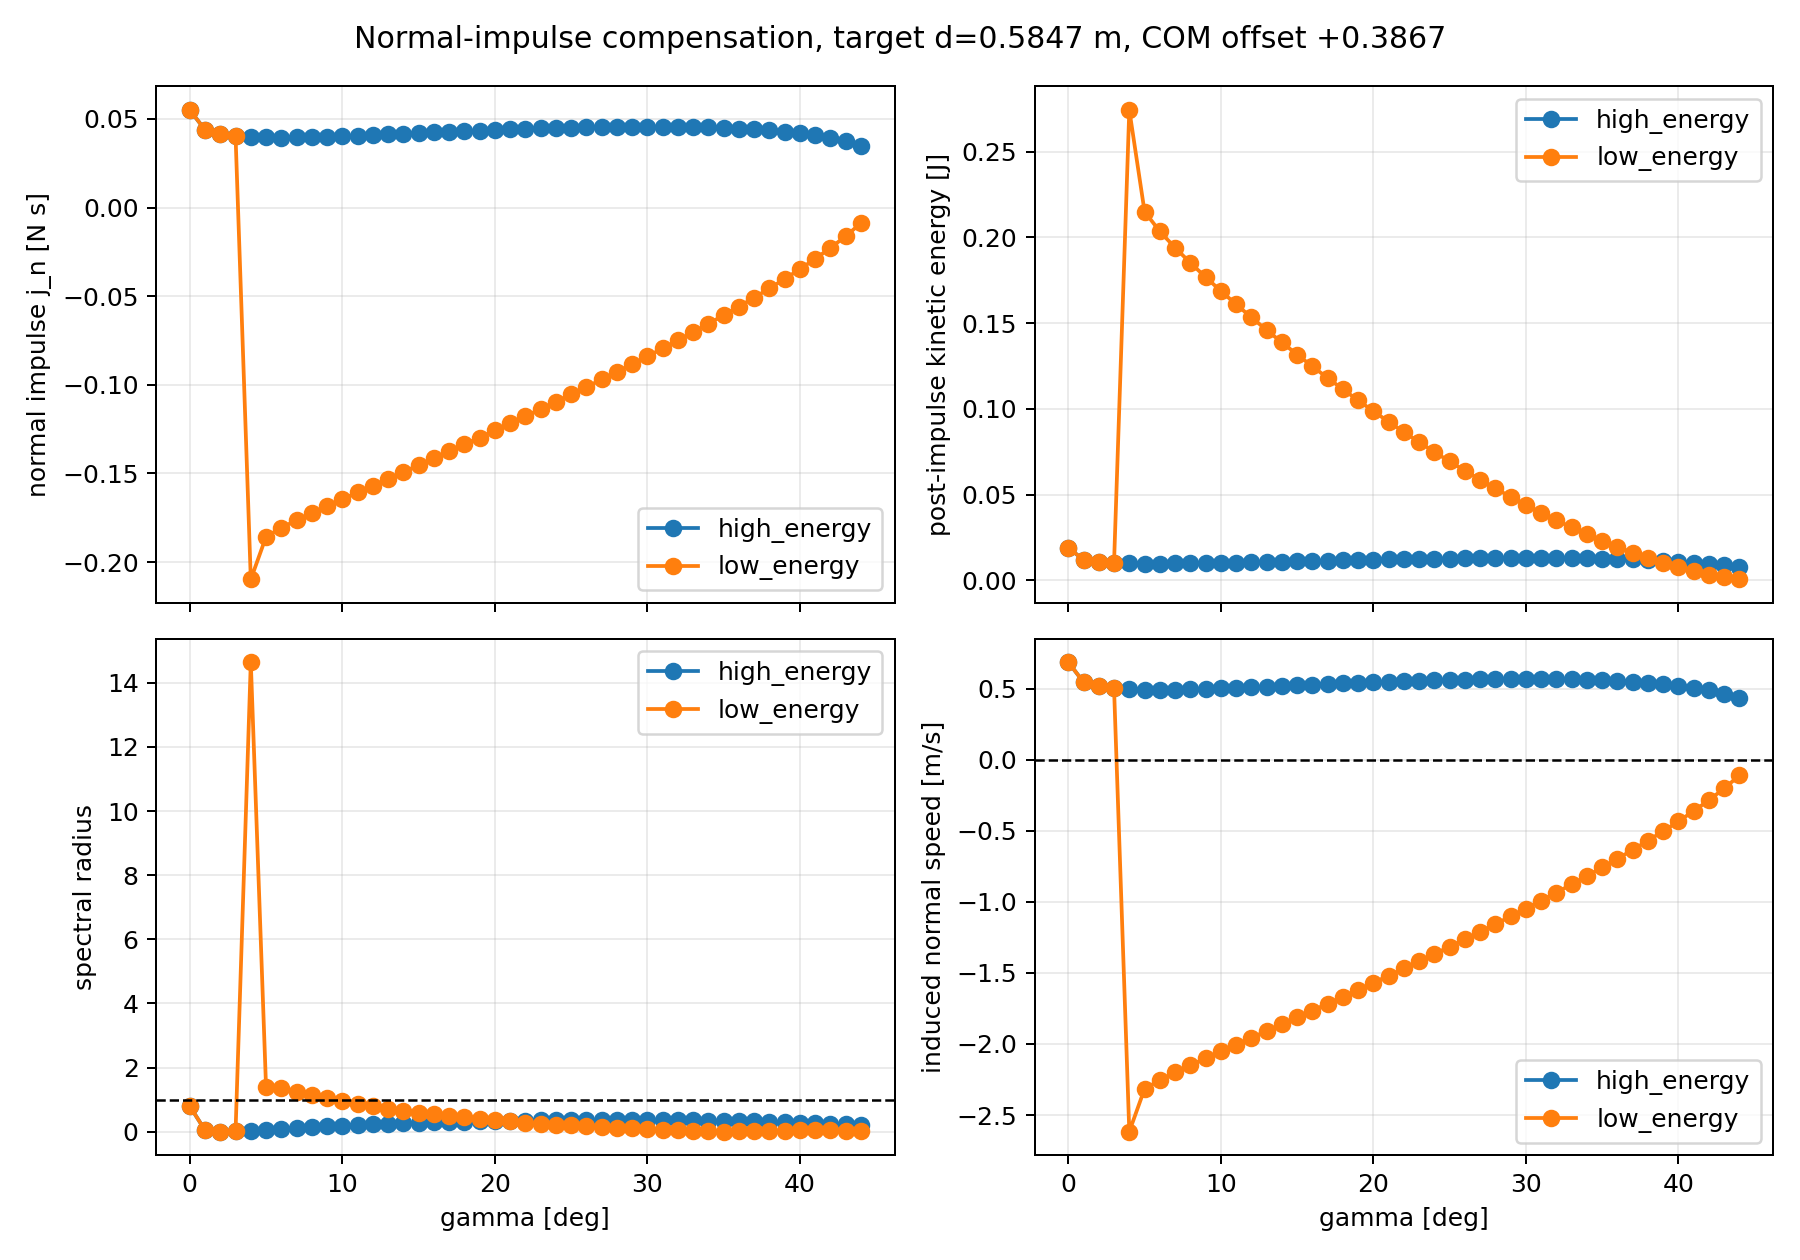

In [10]:
from run_normal_impulse_gamma_continuation import run as run_normal_impulse

part6 = run_normal_impulse(force=FORCE, results_dir=RESULTS_DIR)
show(part6)

## 7. Free Initial Velocity Under Non-Penetration

Allow any endpoint velocity direction that does not point into the wall, and select the legal stable minimum-energy solution.

[free_initial_velocity_gamma_sweep] cache hit (f2084d6b3609); reused 1 figure(s).
results\free_initial_velocity_gamma_sweep_f2084d6b3609__main.png


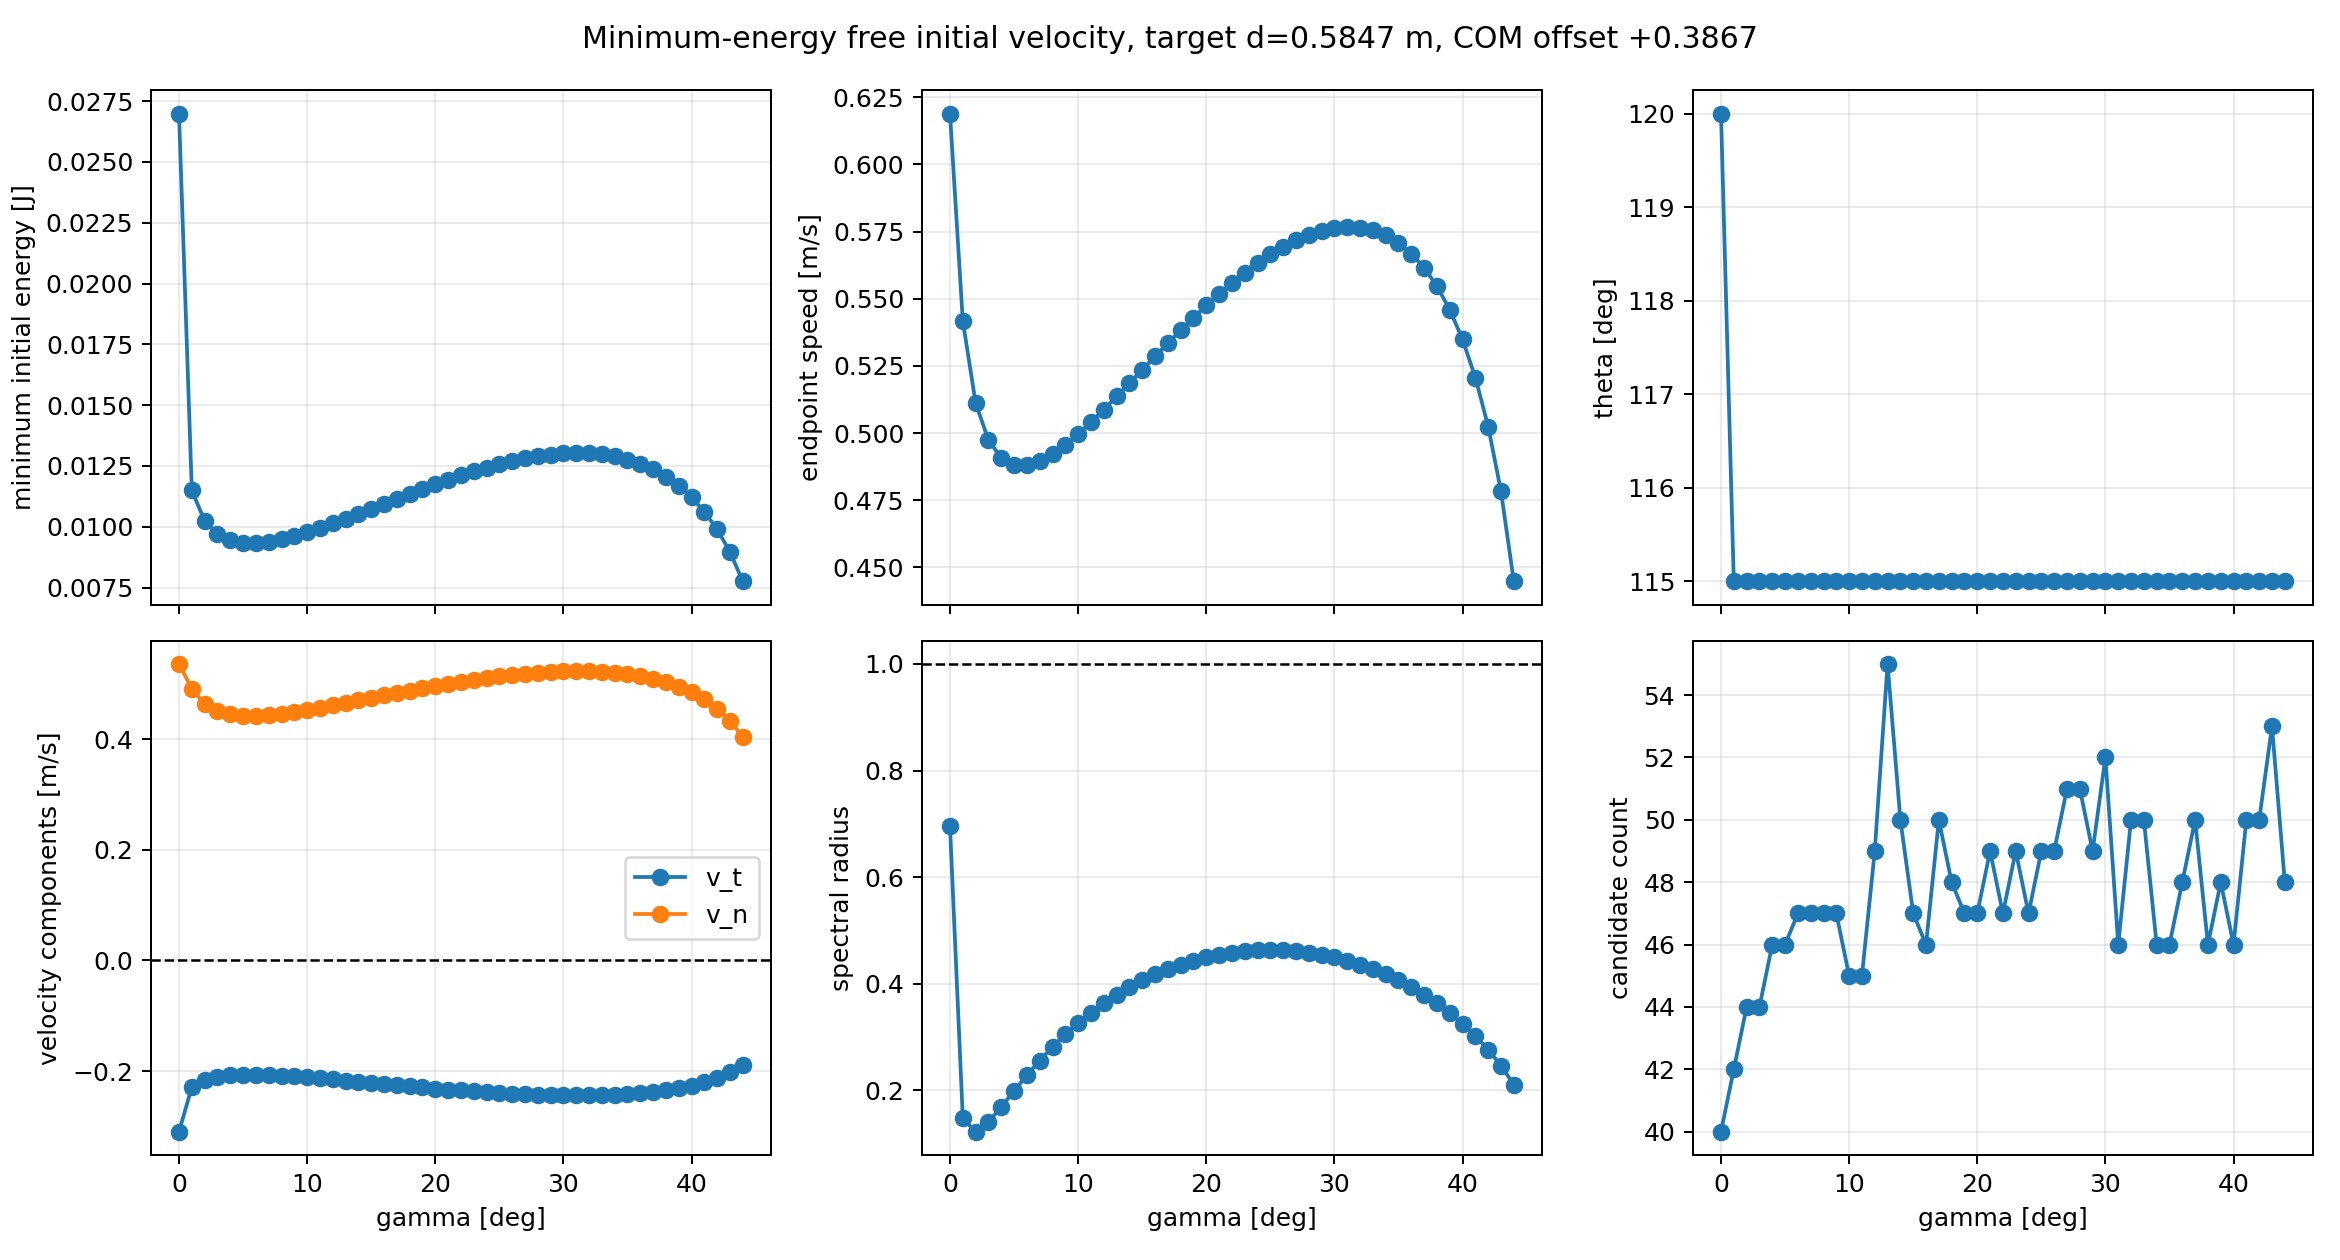

In [11]:
from run_free_initial_velocity_gamma_sweep import run as run_free_velocity

part7 = run_free_velocity(force=FORCE, results_dir=RESULTS_DIR)
show(part7)

## 8a. Direct Collocation Control

Use the gamma=0 minimum-energy free-velocity gait as a reference, then solve a direct-collocation elbow-torque tracking problem. The figure shows torque, system energy, state residual, and external work.

[direct_collocation_gamma0_reference] cache hit (348e7110423e); reused 1 figure(s).
results\direct_collocation_gamma0_reference_348e7110423e__main.png


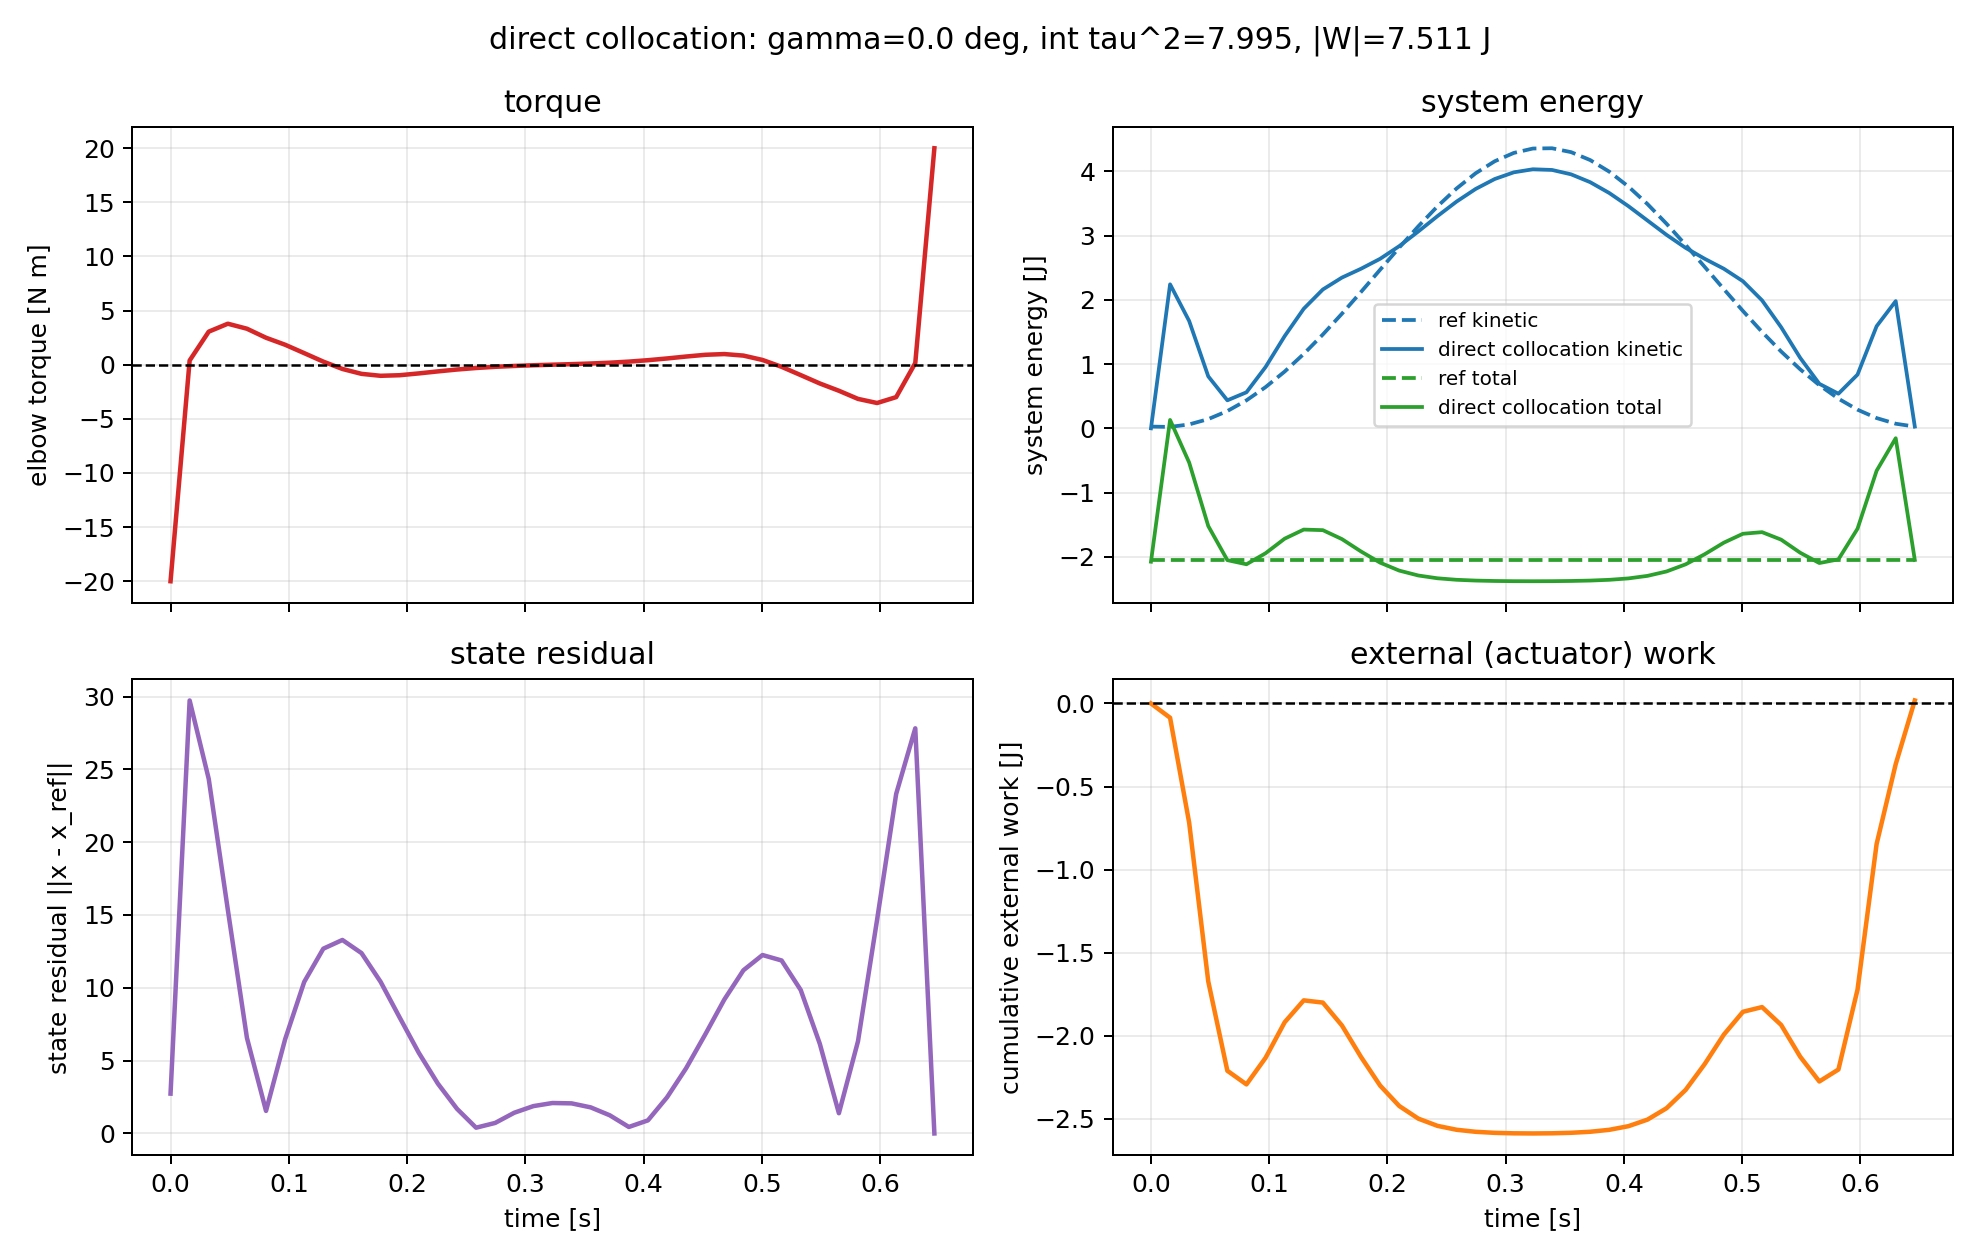

{'absolute_mechanical_work': 7.510792446691251,
 'branch': 'negative',
 'com_offset': 0.38666666666666644,
 'constraint_inf_norm': 1.2886225420061237e-10,
 'd_target': 0.5846703938339892,
 'gamma': 0.0,
 'mechanical_work': 0.01802870863702344,
 'objective': 179.37764230551554,
 'reference_energy_J': 0.026986109894357534,
 'source_com': 'results\\com_sweep_latest.npz',
 'success': True,
 'torque_squared_integral': 7.995346331333708,
 'tracking_rmse': 10.962250474432086}

In [12]:
from run_direct_collocation_gamma0_reference import run as run_dircol

part8a = run_dircol(force=FORCE, results_dir=RESULTS_DIR)
show(part8a)
part8a.summary

## 8b. iLQR Control

Use the same gamma=0 pre-impact swing reference and compare a local iLQR controller against direct collocation.

[ilqr_gamma0_reference] cache hit (cf8101976048); reused 1 figure(s).
results\ilqr_gamma0_reference_cf8101976048__main.png


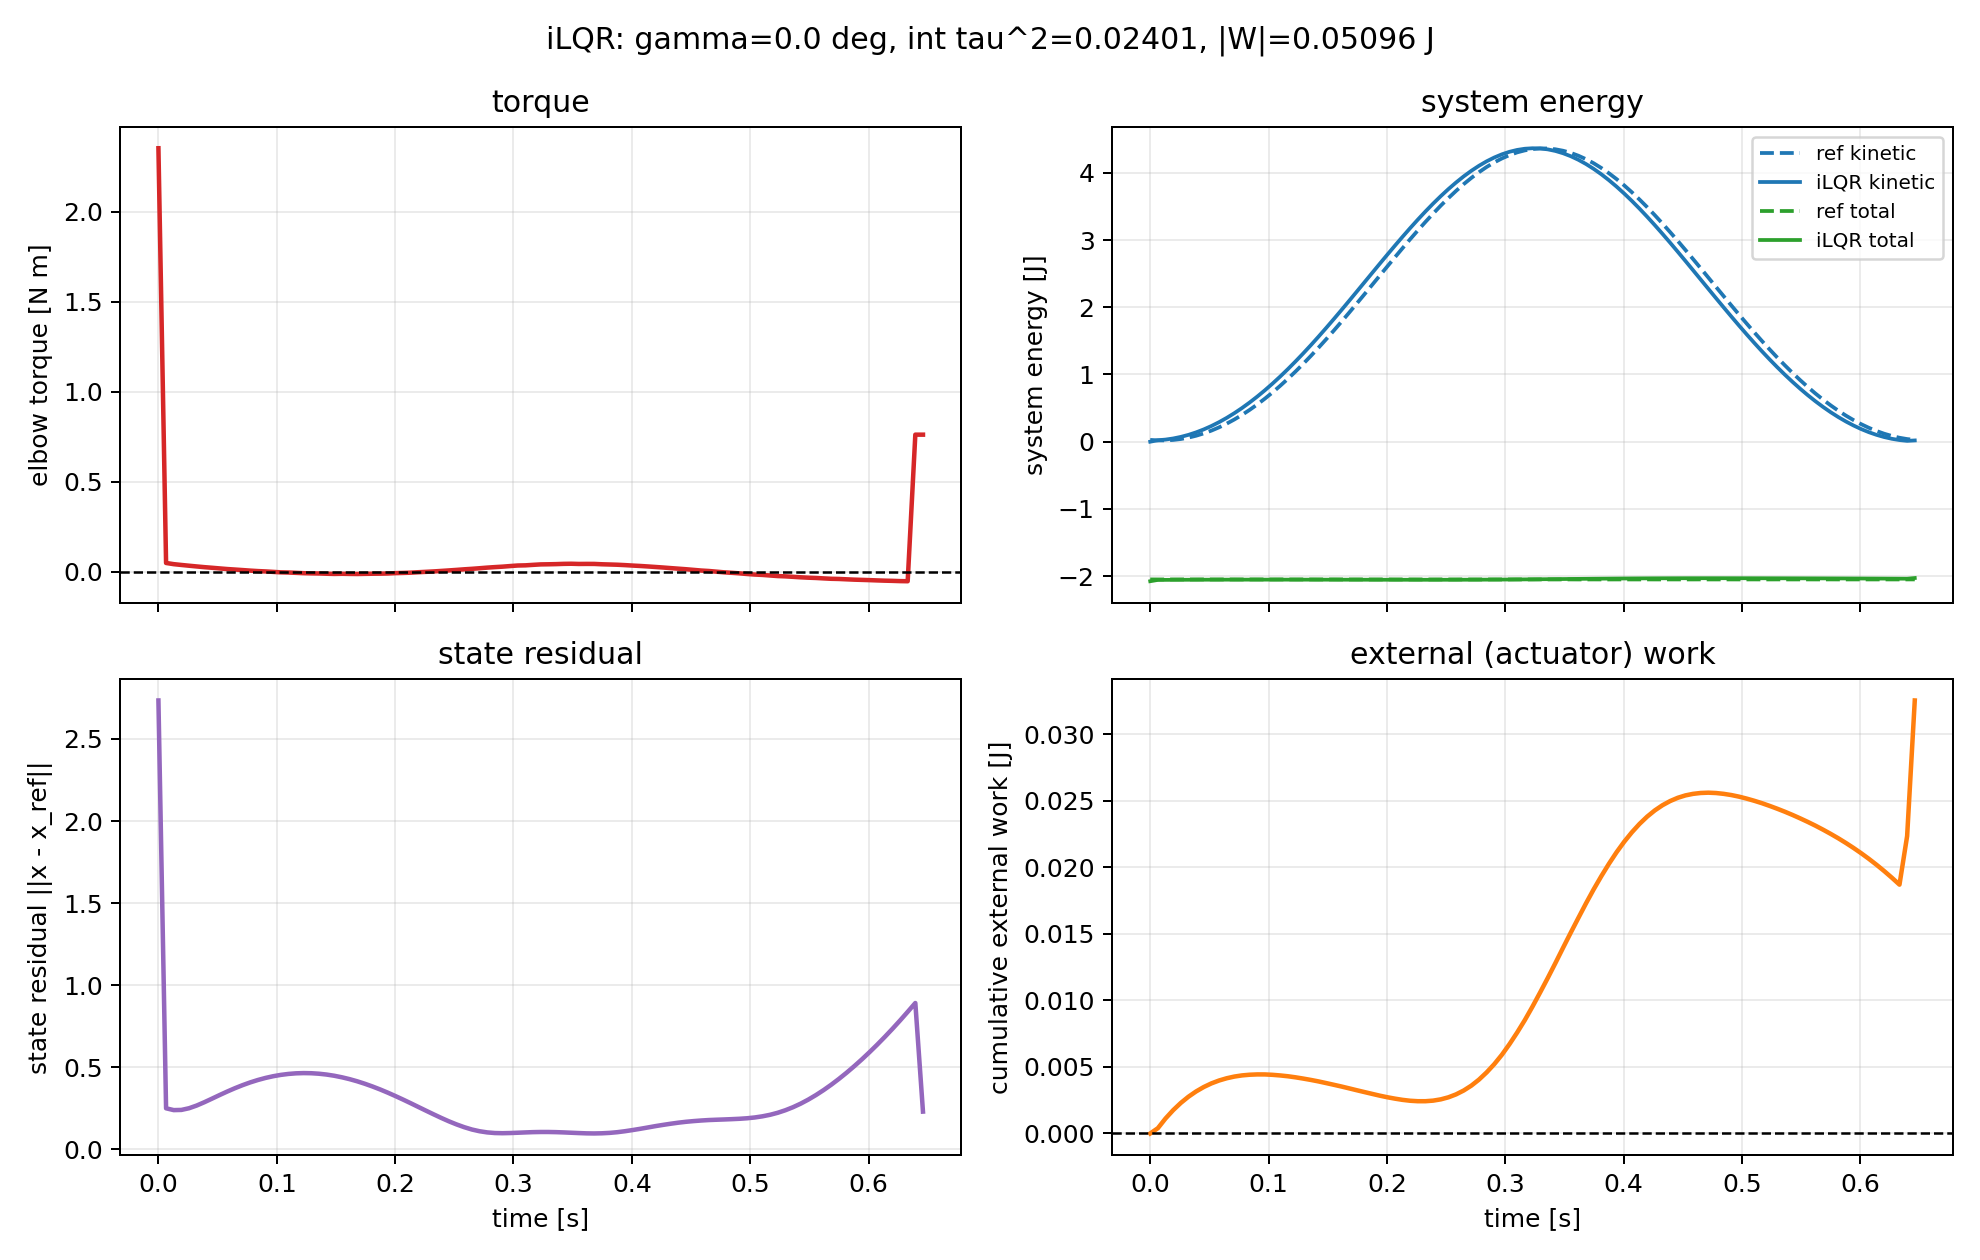

{'absolute_mechanical_work': 0.05095756162605382,
 'branch': 'negative',
 'com_offset': 0.38666666666666644,
 'cost': 0.8758512895808863,
 'd_target': 0.5846703938339892,
 'gamma': 0.0,
 'iterations': 7,
 'mechanical_work': 0.032540607661542285,
 'reference_energy_J': 0.026986109894357534,
 'source_com': 'results\\com_sweep_latest.npz',
 'terminal_error_norm': 0.22903285682007662,
 'torque_squared_integral': 0.02400810476490028,
 'tracking_rmse': 0.4327664449854191}

In [13]:
from run_ilqr_gamma0_reference import run as run_ilqr

part8b = run_ilqr(force=FORCE, results_dir=RESULTS_DIR)
show(part8b)
part8b.summary

## 9. Partial-Loss Instantaneous Collision

Switch collision mode so that the system releases at the instant of impact while retaining part of its kinetic energy, then continue the legal/stable fixed gait in the retention parameter.

[part9_partial_loss] cache hit (9cb6711885d0); reused 1 figure(s).
results\part9_partial_loss_9cb6711885d0__main.png


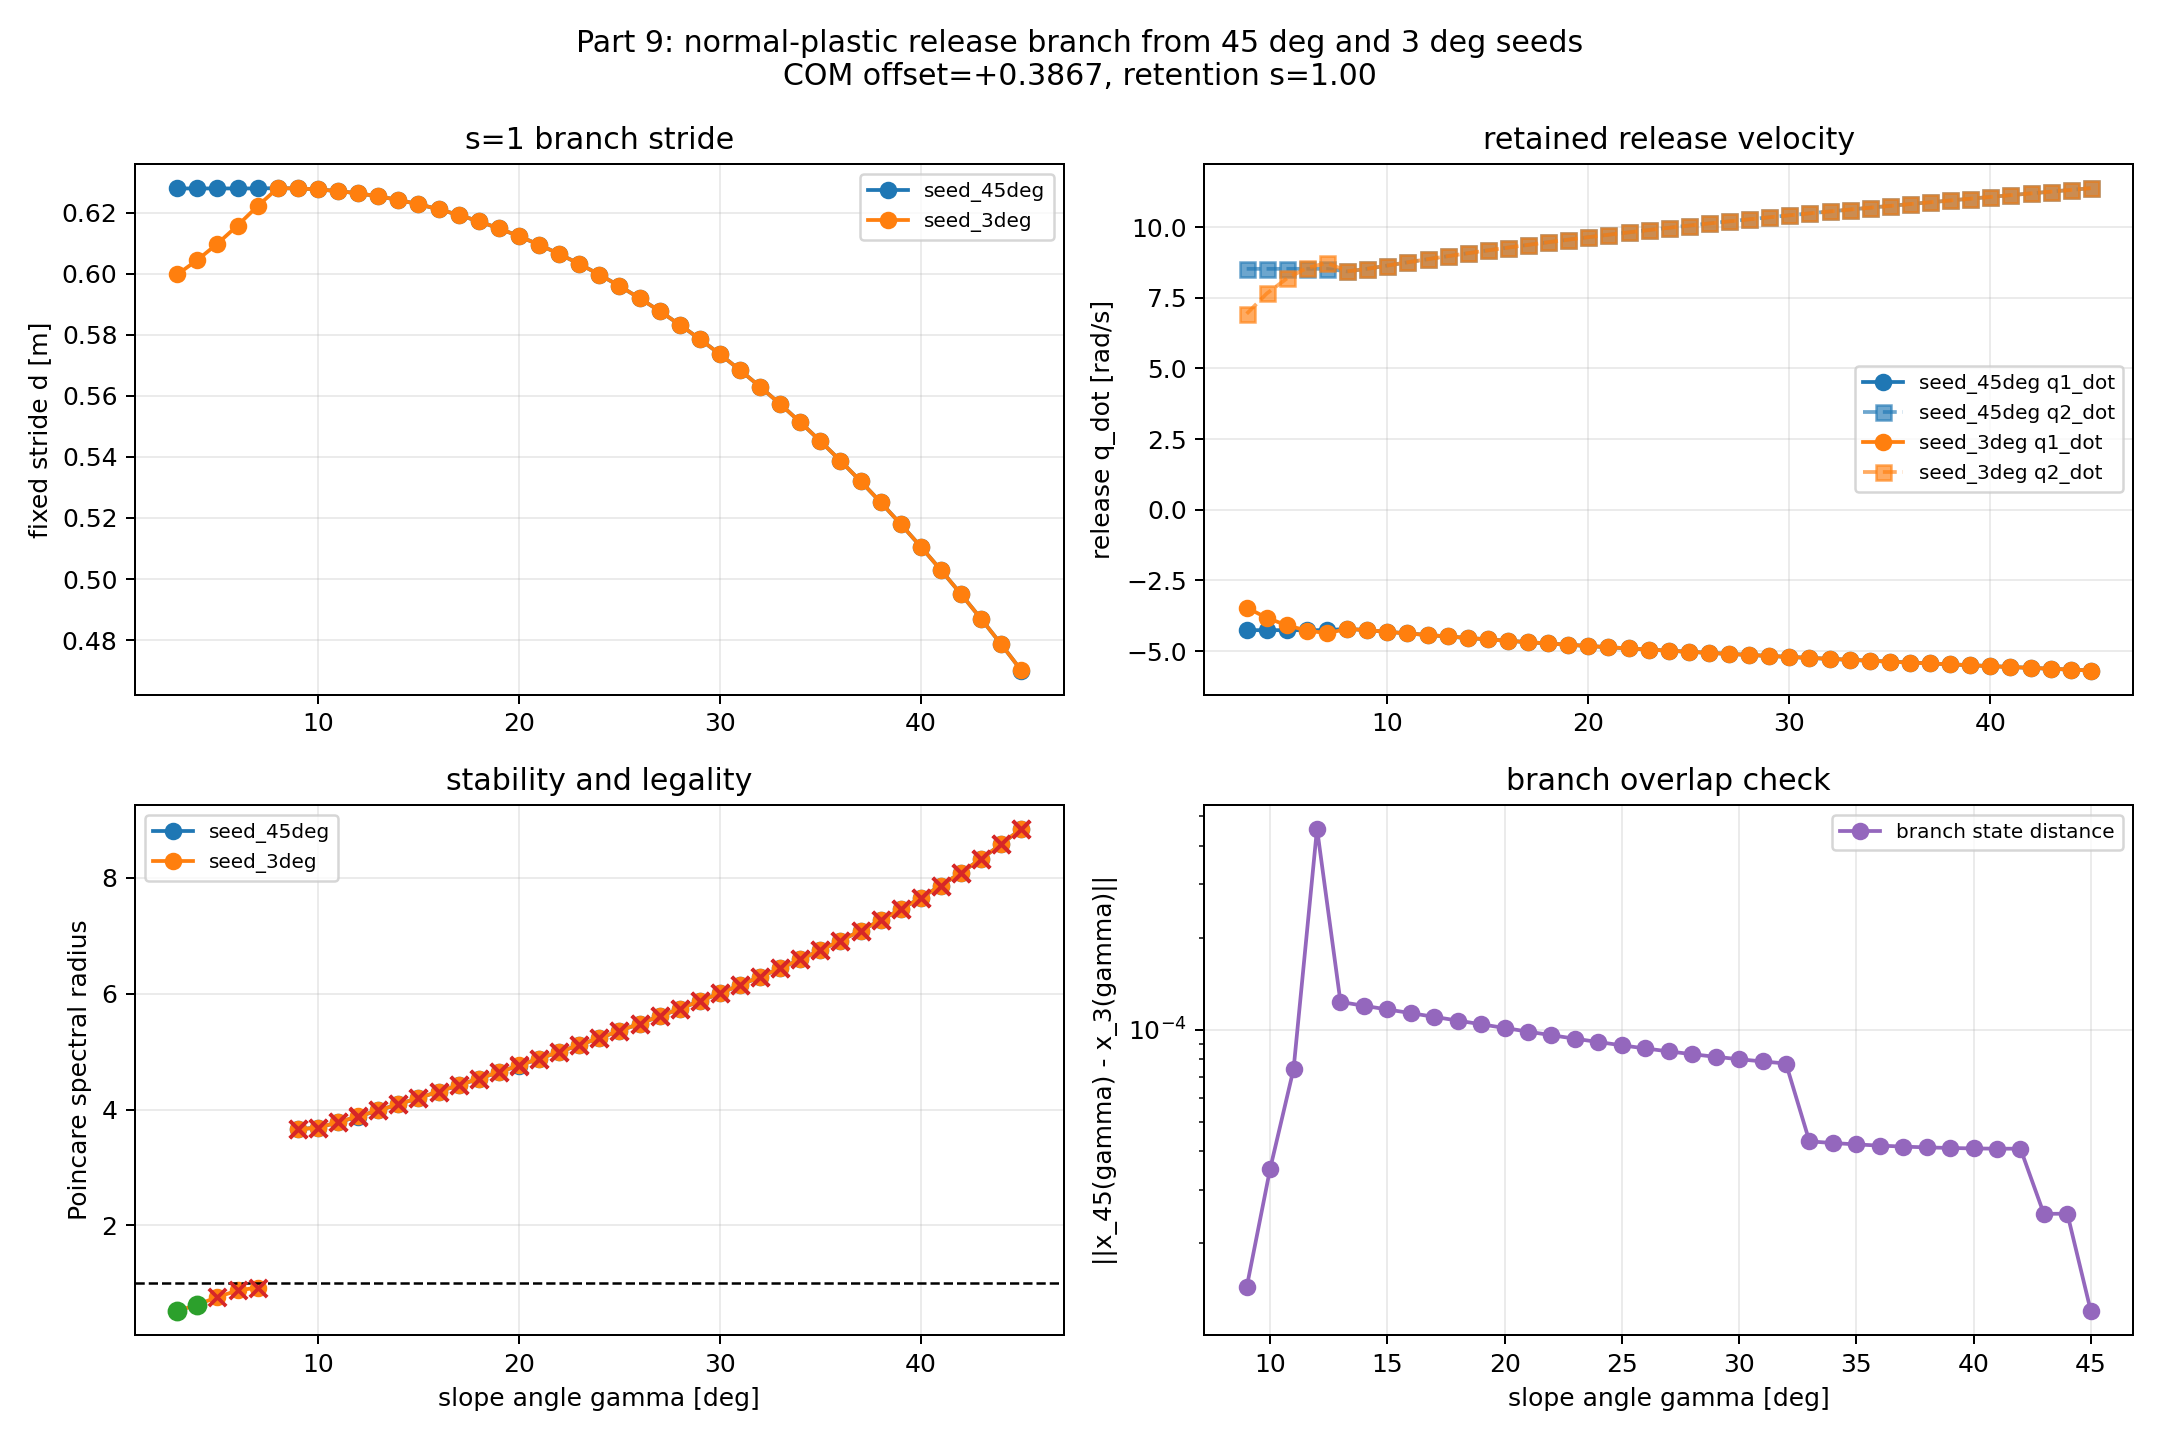

{'branch': 'negative',
 'branch_distance_max': 0.00045475218216613255,
 'branch_distance_rms': 0.00010703651820675279,
 'branch_overlap_points': 37,
 'com_offset': 0.38666666666666644,
 'd_target_full_grab': 0.5846703938339892,
 'gamma_high': 45.0,
 'gamma_low': 3.0,
 'num_points': 86,
 'num_stable_legal': 2,
 'retention': 1.0,
 'seed_high_gamma': 45.0,
 'seed_high_rho': 8.850854963883236,
 'seed_low_gamma': 3.0,
 'seed_low_rho': 0.5204140059163798,
 'stable_legal_gammas': [3.0, 4.0]}

In [14]:
from run_part9_partial_loss import run as run_part9

part9 = run_part9(force=FORCE, results_dir=RESULTS_DIR)
show(part9)
part9.summary